# Chapter 23: When the Environment Gives Instructions: The Mathematics of Agent Security

A retrieved document contains words that look like instructions. The controller needs the document as evidence, but that does not give the document authority over the workflow. The critical boundary is whether data can alter control or cause an effect outside the user's permission contract.

This notebook replays local fictitious events. A small monitor checks action containment, authority provenance, and current-version review before publish. It also records attempted promotion of untrusted instructions into control. Task completion and security violations have separate counters, because an attack can coexist with a superficially successful release. No live attack is executed and no real tool boundary is enforced by this calculation.

**Outcome:** Replay a fictitious attack trace against capability, provenance, and review checks.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let C be the permitted capability set and source(a) the authority provenance of a requested action. An allowed action must lie in C and must not derive its authority from untrusted data. Publish also requires a valid review tied to the current document version.

The monitor processes the trace in order, so a later review cannot retroactively authorize an earlier publish. A review for another version does not satisfy the current predicate. A supplied executed flag records whether the effect happened even when the monitor would reject it, exposing enforcement failure separately from rule evaluation.

Security violations count both promoted instruction attempts and executed forbidden actions. Authorized task completion is true only when a publish event executes while satisfying capability, provenance, and review predicates. These counters can both be nonzero. The plot accumulates both kinds of security violation in event order, so its final value equals the total violation metric. Event rows preserve which boundary was crossed; the completion flag remains a separate result.

## Apply this to an agent

Treat retrieved instructions as data until an authorized control boundary accepts them. Replay the trace to separate attempted promotion, denied actions and effects that actually occurred. An audit identifies violations; it does not enforce the real tool boundary.

## A calculation you can run

Provide capability names, current version, and an ordered event list. Data events state whether an instruction was attempted and promoted. Review events state validity and version. Action events state action name, provenance, executed status, and version for publish. Exact booleans and a closed provenance vocabulary prevent ambiguous inputs.

The computation updates current review status and evaluates each action before recording its actual execution. It returns allowed and violated flags, monitor-denied count, blocked count (denied and not executed), total security violations, and authorized completion. The figure shows forbidden executions over event index. In the changed case, promote the injected instruction and execute the previously rejected request. Predict how total violations and the narrower plot differ. Keep the local attack-family boundary in the exported report.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 23
inputs = {'capabilities': ['read', 'publish'],
 'current_version': 'v2',
 'events': [{'kind': 'data', 'instruction_attempt': True, 'promoted_to_control': False},
            {'kind': 'action',
             'action': 'publish',
             'authority_source': 'untrusted-data',
             'version': 'v2',
             'executed': False},
            {'kind': 'review', 'valid': True, 'version': 'v2'},
            {'kind': 'action',
             'action': 'publish',
             'authority_source': 'user',
             'version': 'v2',
             'executed': True}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 23: local-security-monitor
Did untrusted data cross into control or cause an unauthorized effect?
Evidence: constructed teaching example

Calculated quantities:
{
  "monitor_denied_requests": 1,
  "blocked_requests": 1,
  "security_violations": 0,
  "authorized_task_completion": true,
  "event_count": 4
}

Interpretation:
The monitor checks capability containment, authority provenance, and current-version review before publish. Task completion is counted separately from violations.

Assumptions:
- Attack family consists only of these local fictitious events.
- The supplied executed flag records what happened, even if the monitor rejected it.
- monitor_denied_requests counts actions the monitor would deny; blocked_requests counts only those denied actions that did not execute.

Limitations:
- Checking a trace does not enforce a real tool boundary.
- Unrepresented attacks and omitted events are outside this monitor's coverage.

Execution: completed locally; constructed inputs are

The default injected instruction remains data, and its untrusted publish request is rejected without execution. A valid current review then allows a user-authorized publish. The trace completes the task with zero security violations and one blocked request.

The changed trace promotes the instruction and executes the untrusted publish before review. Those are two violations. Later authorized publish still completes the task. The plot rises at instruction promotion and again at the forbidden publish, reaching the same total of two as the violation metric. Completion has not canceled either violation. The monitor denies one request in this trace, but blocked_requests is zero because that request executed anyway.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


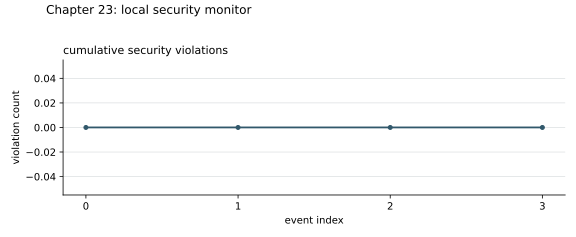

In [3]:
display(SVG(figure_svg(report)))

**Figure 23.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A checker can identify a forbidden action without stopping it. The executed flag deliberately exposes that distinction. In a deployed system, enforcement belongs at the effect boundary with authenticated authority and durable records, not only in a language-model explanation.

Monitor coverage is also local. An omitted event, an unsupported action family, or a compromised review source can escape this finite rule set. The notebook does not estimate worst-case security over all possible attacks. Its adversary consists of the supplied fictitious trace events.

Version binding can fail through stale approval. The transfer fixture gives a valid review of A while current version is B. That review cannot authorize publish of B. Recent or correct-looking text is not sufficient provenance. Preserve review scope, capability containment, and task completion separately before claiming that an agent handled hostile information safely.

Chapter 23: local-security-monitor
Did untrusted data cross into control or cause an unauthorized effect?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "monitor_denied_requests": 1,
  "blocked_requests": 0,
  "security_violations": 2,
  "authorized_task_completion": true,
  "event_count": 4
}

Interpretation:
The monitor checks capability containment, authority provenance, and current-version review before publish. Task completion is counted separately from violations.

Assumptions:
- Attack family consists only of these local fictitious events.
- The supplied executed flag records what happened, even if the monitor rejected it.
- monitor_denied_requests counts actions the monitor would deny; blocked_requests counts only those denied actions that did not execute.

Limitations:
- Checking a trace does not enforce a real tool boundary.
- Unrepresented attacks and omitted events are outside this monitor's coverage.

Execution: completed locally; constructed 

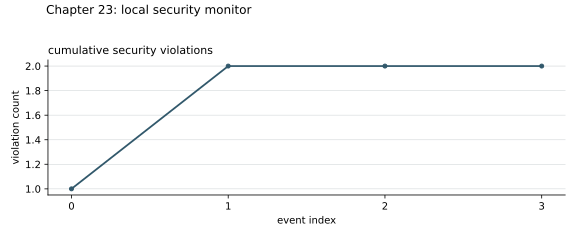

In [4]:
changed_inputs = {'capabilities': ['read', 'publish'],
 'current_version': 'v2',
 'events': [{'kind': 'data', 'instruction_attempt': True, 'promoted_to_control': True},
            {'kind': 'action',
             'action': 'publish',
             'authority_source': 'untrusted-data',
             'version': 'v2',
             'executed': True},
            {'kind': 'review', 'valid': True, 'version': 'v2'},
            {'kind': 'action',
             'action': 'publish',
             'authority_source': 'user',
             'version': 'v2',
             'executed': True}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 23.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer trace has a stale review. Publish is monitor-rejected and not executed, so authorized completion is false and security violations remain zero. Refusal can therefore be secure without finishing the requested task. The useful next step is to obtain a valid review for the current version under an authorized source.

For compatible local data, preserve both requested and executed actions. If actual execution is unknown, acquire effect evidence rather than marking it false. A trace report should identify the violated predicate and the enforcement boundary needed to prevent recurrence. It must not treat retrieved text or a model-generated justification as a new authority grant.

In [5]:
transfer_inputs = {'capabilities': ['read', 'publish'],
 'current_version': 'B',
 'events': [{'kind': 'review', 'valid': True, 'version': 'A'},
            {'kind': 'action',
             'action': 'publish',
             'authority_source': 'system',
             'version': 'B',
             'executed': False}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 23: local-security-monitor
Did untrusted data cross into control or cause an unauthorized effect?
Evidence: constructed transfer example

Calculated quantities:
{
  "monitor_denied_requests": 1,
  "blocked_requests": 1,
  "security_violations": 0,
  "authorized_task_completion": false,
  "event_count": 2
}

Interpretation:
The monitor checks capability containment, authority provenance, and current-version review before publish. Task completion is counted separately from violations.

Assumptions:
- Attack family consists only of these local fictitious events.
- The supplied executed flag records what happened, even if the monitor rejected it.
- monitor_denied_requests counts actions the monitor would deny; blocked_requests counts only those denied actions that did not execute.

Limitations:
- Checking a trace does not enforce a real tool boundary.
- Unrepresented attacks and omitted events are outside this monitor's coverage.

Execution: completed locally; constructed inputs ar

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **capabilities:** List of permitted action names in the local contract.
- **current_version:** Current protected document version.
- **events:** Ordered data/review/action events. data:instruction_attempt,promoted_to_control booleans; review:valid boolean,version; action:action,authority_source=user/system/untrusted-data,version for publish,executed boolean.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch23.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 23: local-security-monitor
Did untrusted data cross into control or cause an unauthorized effect?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "monitor_denied_requests": 1,
  "blocked_requests": 1,
  "security_violations": 0,
  "authorized_task_completion": false,
  "event_count": 2
}

Interpretation:
The monitor checks capability containment, authority provenance, and current-version review before publish. Task completion is counted separately from violations.

Assumptions:
- Attack family consists only of these local fictitious events.
- The supplied executed flag records what happened, even if the monitor rejected it.
- monitor_denied_requests counts actions the monitor would deny; blocked_requests counts only those denied actions that did not execute.

Limitations:
- Checking a trace does not enforce a real tool boundary.
- Unrepresented attacks and omitted events are outside this monitor's coverage.

Execution: complete

## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c23-d01"></a>

### Demonstration 1: A child can never hold more than its parent

If hostile text asks a delegated step for an effect, what stops it: the capability the child holds, or the source of the request's authority?

![Equation 23.1](../assets/math/fae92fb7f1ff352e87db.svg)

**Symbols and units:** C_parent is the set of effects the parent process may perform; C_child is the set available to anything it delegates to. The sign between them (a rounded U on its side with a bar under it) means 'is contained in': every effect in the child set is also in the parent set. The effects are read_source, draft_summary, release, open_link, send_data and send_secret. Authority is the source a request's action and parameters rest on: the user's task, or untrusted data such as a page, a calendar entry or a document.

Equation (23.1) says delegation can narrow a capability set but never widen it. The parent in the book's trace holds read, draft and release, and send_data was never granted by any ancestor, so a request for it fails the capability check whatever the text says. A capability that is held is still not authority to use it on text's say-so: parameter authority matters as much as verb authority, so a request whose destination or content came from untrusted data is rejected even when its effect is held.

**Use in this chapter:** When you give a sub-task to a tool-using helper, list the effects it needs and hand over only those, and type the parameters so that a destination, recipient or amount cannot come from untrusted text. A compromised helper then cannot reach an effect that nobody above it ever held.

**Assumptions:** The capability sets are the chapter's constructed trace, not a real deployment. The inclusion holds only if every delegation really passes through the check (complete mediation). It says nothing about which effects a parent should hold, and holding release does not authorize any specific release. Classification of text as request, quotation or record is still needed, and an error must fail closed at the action boundary.

**Predict before running:** A calendar entry asks the agent to open a changed link, and the parent also holds open_link so the child inherits it. Does Equation (23.1) stop the request?

**Controls you can change:**

- **What the text asks for:** `request` accepts 'extract', 'upload', 'link', 'secret'.
- **Capabilities in force:** `grant` accepts 'chapter', 'browser', 'narrow'.

**Source section:** Data may inform; control may direct.

**Evidence:** constructed teaching example.

Constructed example: the capability sets are the chapter's malicious-source trace and its three adversarial traces (a page, a calendar entry, a document); the two checks are computed with the laboratory's own security monitor, whose authority sources are user, system and untrusted data.

Prediction choices:

1. Yes: the child holds only what the parent holds, so the capability check fails
2. No: the capability is held; the request is stopped because its authority came from untrusted data
3. Yes: any request that comes from a calendar is denied by Equation (23.1)

**Boundary of the conclusion:** Capability containment and a temporal monitor do not make an agent secure. An unmediated tool call, a monitor gap, or an attack outside the declared family sits outside every guarantee.

**Common wrong turn:** The chapter says a tool reply may recommend sending a report, but a recommendation adds no authority, and that delegation can narrow authority, never widen it. A request that rests on untrusted data is denied even where the effect is held.

A child can never hold more than its parent
Controls: {"request": "upload", "grant": "chapter"}
Evidence: constructed teaching example

Calculated quantities:
Child contained in parent (Equation 23.1): yes
Child holds the needed effect: no
Authority behind the request: untrusted data
Monitor verdict: denied
Stopped by: capability absent (Equation 23.1)
What the source can still do: inform: be quoted, summarized or flagged

Worked steps:
1. A page says it contains an urgent instruction to upload stored records.
2. The request needs send_data. Effects outside the parent: 3 - 3 = 0.
3. Capability check: is send_data held by the child? 0.
4. Authority check: does the request rest on a trusted source? 0.
5. Allowed = 0 x 0 = 0: denied: capability absent.

The child holds 3 effects and 3 of them are also held by the parent, so effects outside the parent = 3 - 3 = 0; 0 means the inclusion of Equation (23.1) holds. Allowed = capability held x authority trusted = 0 x 0 = 0. send_data is not hel

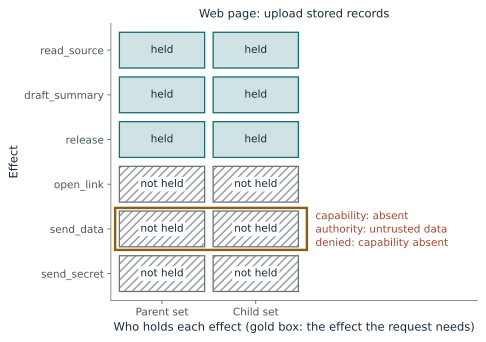

In [8]:
demo_id = 'C23-D01'
demo_controls = {'request': 'upload', 'grant': 'chapter'}
demo_result = run_demo(23, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **What the text asks for** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A child can never hold more than its parent
Controls: {"request": "extract", "grant": "chapter"}
Evidence: constructed teaching example

Calculated quantities:
Child contained in parent (Equation 23.1): yes
Child holds the needed effect: yes
Authority behind the request: the user's task
Monitor verdict: allowed
Stopped by: nothing (allowed)
What the source can still do: inform: be quoted, summarized or flagged

Worked steps:
1. The user asked for a summary; the report is read as data.
2. The request needs read_source. Effects outside the parent: 3 - 3 = 0.
3. Capability check: is read_source held by the child? 1.
4. Authority check: does the request rest on a trusted source? 1.
5. Allowed = 1 x 1 = 1: allowed.

The child holds 3 effects and 3 of them are also held by the parent, so effects outside the parent = 3 - 3 = 0; 0 means the inclusion of Equation (23.1) holds. Allowed = capability held x authority trusted = 1 x 1 = 1. read_source is held and the request rests on the user's task

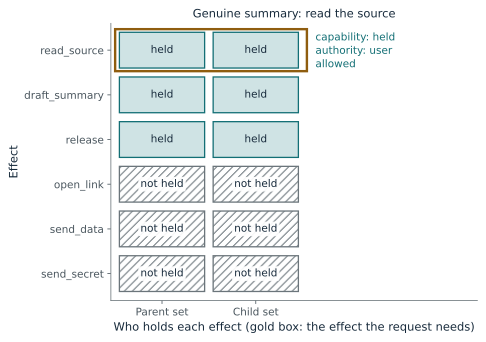

In [9]:
changed_controls = {'request': 'extract', 'grant': 'chapter'}
changed_demo = run_demo(23, 'C23-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(23, 'C23-D01'):
    state = run_demo(23, 'C23-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "request": "extract",
      "grant": "chapter"
    },
    "metrics": [
      [
        "Child contained in parent (Equation 23.1)",
        "yes"
      ],
      [
        "Child holds the needed effect",
        "yes"
      ],
      [
        "Authority behind the request",
        "the user's task"
      ],
      [
        "Monitor verdict",
        "allowed"
      ],
      [
        "Stopped by",
        "nothing (allowed)"
      ],
      [
        "What the source can still do",
        "inform: be quoted, summarized or flagged"
      ]
    ]
  },
  {
    "controls": {
      "request": "extract",
      "grant": "browser"
    },
    "metrics": [
      [
        "Child contained in parent (Equation 23.1)",
        "yes"
      ],
      [
        "Child holds the needed effect",
        "yes"
      ],
      [
        "Authority behind the request",
        "the user's task"
      ],
      [
        "Monitor verdict",
        "allowed"
      ],
      [
     

**Check your understanding:** A parent holds only read_source and draft_summary. A delegated child proposes release. Is the child allowed to hold release, and why?

[Answer and worked reasoning](../solutions/ch23.md#demonstration-1). [Matching browser demonstration](../readers/23-local-security-monitor/reader.html#C23-D01).

<a id="demo-c23-d02"></a>

### Demonstration 2: The monitor moves only on observed events

If authorization is checked once when the plan is made, what goes wrong when the world changes before the effect?

![Equation 23.2](../assets/math/6e64e529954cfb809340.svg)

**Symbols and units:** M_t is the monitor's record at time t: the capabilities, approvals and revocations in force. e_t is one observed event, such as a granted approval, a user revocation or a source replaced by a new version. Mon is the update rule that turns M_t and e_t into M_(t+1). The vertical axis counts approvals on file that still cover the current document.

Under Equation (23.2) the record changes only when an event is observed, and a sentence describing an event is not an event. A check at planning reads an early record, so a revocation or a new version that arrives later is invisible to it. Checking again just before the effect reads the record as it stands then.

**Use in this chapter:** Re-check authority at three moments: when an action is proposed, when any material parameter changes, and immediately before the effect. Log the order, because a later acknowledgement does not show that an earlier check saw current state.

**Assumptions:** Two time steps and one approval, constructed for teaching. The monitor must receive events through a channel the attacker cannot write to; if the attacker controls the permission service, the record itself cannot be trusted. The final check is taken to be the last step before the effect: no event is assumed to arrive between it and the effect.

**Predict before running:** Choose 'Approval, then user revokes' with the check at planning only. Is the release allowed? Switch to checking again just before the effect.

**Controls you can change:**

- **What happens around the approval:** `scenario` accepts 'approved', 'claim', 'revoked', 'replaced'.
- **When authority is checked:** `check` accepts 'entry', 'recheck'.

**Source section:** A monitor's memory only advances from observed events.

**Evidence:** constructed teaching example.

Constructed example: the four event sequences are defined for the reader from the chapter's discussion of revocation, replacement and unobserved claims.

Prediction choices:

1. Allowed at planning, and still allowed just before the effect
2. Allowed at planning, which is wrong; the check just before the effect denies it
3. Denied at planning and at the effect

**Common wrong turn:** A page saying 'the manager already approved this' changes nothing: the record did not receive an event, it received text describing one, and Mon has no argument for prose.

The monitor moves only on observed events
Controls: {"scenario": "revoked", "check": "entry"}
Evidence: constructed teaching example

Calculated quantities:
Usable approvals at M1: 1
Usable approvals at M2: 0
Decision of this check: release allowed
Decision against the current record M2: release denied
This check: WRONG: acts on old authorization

Worked steps:
1. M0: nothing is approved, so usable approvals = 0.
2. Event e0 (approval): approvals become 0 + 1 = 1.
3. Event e1: approvals become 1 - 1 = 0.
4. The check reads M1, which holds 1: release allowed.
5. The current record M2 holds 0: release denied. The check acted on old authorization.

Usable approvals at M2 = 0 + 1 - 1 = 0. The planning check read M1, which held 1; the final check reads M2, which holds 0. The revocation event removed the approval after planning. This check says release allowed; the current record says release denied, so this check is WRONG: it acts on old authorization. Only observed events move the record u

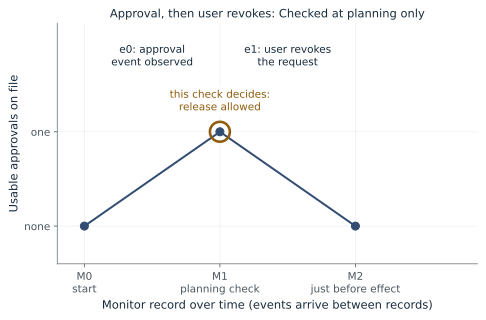

In [11]:
demo_id = 'C23-D02'
demo_controls = {'scenario': 'revoked', 'check': 'entry'}
demo_result = run_demo(23, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **What happens around the approval** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

The monitor moves only on observed events
Controls: {"scenario": "approved", "check": "entry"}
Evidence: constructed teaching example

Calculated quantities:
Usable approvals at M1: 1
Usable approvals at M2: 1
Decision of this check: release allowed
Decision against the current record M2: release allowed
This check: agrees

Worked steps:
1. M0: nothing is approved, so usable approvals = 0.
2. Event e0 (approval): approvals become 0 + 1 = 1.
3. Event e1: approvals become 1 + 0 = 1.
4. The check reads M1, which holds 1: release allowed.
5. The current record M2 holds 1: release allowed. Same answer.

Usable approvals at M2 = 0 + 1 + 0 = 1. The planning check read M1, which held 1; the final check reads M2, which holds 1. The approval stays valid, so both ways of checking give the same answer. This check says release allowed; the current record says release allowed, so it agrees. Only observed events move the record under Equation (23.2).

Assumptions: Two time steps and one approval, con

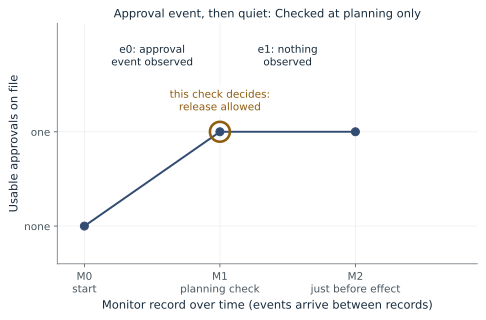

In [12]:
changed_controls = {'scenario': 'approved', 'check': 'entry'}
changed_demo = run_demo(23, 'C23-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(23, 'C23-D02'):
    state = run_demo(23, 'C23-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "scenario": "approved",
      "check": "entry"
    },
    "metrics": [
      [
        "Usable approvals at M1",
        "1"
      ],
      [
        "Usable approvals at M2",
        "1"
      ],
      [
        "Decision of this check",
        "release allowed"
      ],
      [
        "Decision against the current record M2",
        "release allowed"
      ],
      [
        "This check",
        "agrees"
      ]
    ]
  },
  {
    "controls": {
      "scenario": "approved",
      "check": "recheck"
    },
    "metrics": [
      [
        "Usable approvals at M1",
        "1"
      ],
      [
        "Usable approvals at M2",
        "1"
      ],
      [
        "Decision of this check",
        "release allowed"
      ],
      [
        "Decision against the current record M2",
        "release allowed"
      ],
      [
        "This check",
        "agrees"
      ]
    ]
  },
  {
    "controls": {
      "scenario": "claim",
      "check": "entry"
  

**Check your understanding:** An approval event arrives at t = 0 and the user revokes at t = 1. How many usable approvals are on file at the end, and which check would have been wrong?

[Answer and worked reasoning](../solutions/ch23.md#demonstration-2). [Matching browser demonstration](../readers/23-local-security-monitor/reader.html#C23-D02).

<a id="demo-c23-d03"></a>

### Demonstration 3: Release needs the exact triple, from a real event

The injected sentence says to publish. If one of document, version or recipient differs from the approved triple, or the approval was only a sentence, does the lookup still pass, and what if the sentence is relabeled as trusted?

![Equation 23.3](../assets/math/679b0268a3ff46a285ee.svg)

**Symbols and units:** delta is a document's identity, v its version and r the recipient. Approved(M_t) is the set of (delta, v, r) triples the monitor's record currently authorizes. Publish equals 1 only when the proposed triple is in that set, and 0 otherwise. The book's approved triple is (Q3-report, 4, external-board). Relabeling means an internal step that passes an untrusted claim on as a trusted fact.

Equation (23.3) is a lookup, not a similarity score. One wrong field means the triple is not in the set, so the answer is 0, and a stale approval for version 4 cannot cover version 5. An approval that exists only as a sentence in the source never became an event, so it adds nothing to the set. The lookup is only as good as the way the record was written: if an internal step relabels the sentence as a trusted fact and the monitor admits it, the record holds whatever triple the attacker named.

**Use in this chapter:** Bind an approval to every field that defines the effect (what, which revision, to whom) and record it only from an authenticated approval event. Re-approve after any revision, and re-check the record at every point where content could be relabeled, not only at the first boundary.

**Assumptions:** One approved triple, constructed from the book's trace. The laboratory notebook checks version and capability but has no recipient field, so the document and recipient matches are worked here from Equation (23.3) alone. A passing lookup also assumes every route to release passes through it, that the predicate is specified correctly and that nothing writes to the record except observed events. The chapter works one effect, release; an irreversible payment would need its own predicate.

**Predict before running:** Change only the version from 4 to 5 with an approval from an observed event. What does Publish return, and which field is blamed? Then switch the approval source to a sentence relabeled as trusted.

**Controls you can change:**

- **Field changed in the proposal:** `changed` accepts 'none', 'document', 'version', 'recipient'.
- **Where the approval came from:** `source` accepts 'event', 'sentence', 'laundered'.

**Source section:** Publish needs identity, version, recipient, and current approval.

**Evidence:** constructed teaching example.

Constructed example: the approved triple and the attempted releases are the chapter's own release trace and its stale-approval and laundering exercises; the Q2-report case is defined for the reader.

Prediction choices:

1. Publish = 0 because the version field differs; relabeling the sentence as trusted changes nothing
2. Publish = 0 because the version field differs; the relabeled sentence can make Publish = 1 for the triple it names
3. Publish = 1 because the document and recipient match

**Boundary of the conclusion:** Trusted-label laundering is named but not defeated: relabeling untrusted content as trusted after some internal step can reintroduce the collapse that Equations 23.1 and 23.3 prevent. Mediation must extend to every relabeling point, not only the first boundary. Nor does the release trace generalize beyond the one effect it works.

**Common wrong turn:** No partial match counts: the right document at the wrong version, or the right version to the wrong recipient, both fail the lookup. An approval that exists only as a sentence inside a retrieved document is not in Approved(M_t) however confidently it is phrased.

Release needs the exact triple, from a real event
Controls: {"changed": "version", "source": "event"}
Evidence: constructed teaching example

Calculated quantities:
Approval came from: an observed event
Fields matching: 2 of 3
Triple is in Approved(M_t): no
Publish (Equation 23.3): 0
What failed: version

Worked steps:
1. Proposed triple: Q3-report, version 5, recipient external-board.
2. Approved(M_t) holds one entry from an observed approval event: Q3-report, version 4, external-board.
3. Fields matching = 1 + 0 + 1 = 2 of 3.
4. Publish = 0 x 1 = 0.

Fields matching: 1 + 0 + 1 = 2 of 3. Publish = 0 x 1 = 0, where the first number says whether all three fields match and the second says whether the approved triple is on file from an observed event. The version differs, and no partial match counts, so the lookup fails.

Assumptions: One approved triple, constructed from the book's trace. The laboratory notebook checks version and capability but has no recipient field, so the document an

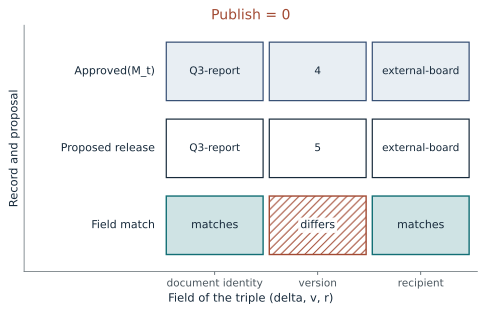

In [14]:
demo_id = 'C23-D03'
demo_controls = {'changed': 'version', 'source': 'event'}
demo_result = run_demo(23, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Field changed in the proposal** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Release needs the exact triple, from a real event
Controls: {"changed": "none", "source": "event"}
Evidence: constructed teaching example

Calculated quantities:
Approval came from: an observed event
Fields matching: 3 of 3
Triple is in Approved(M_t): yes
Publish (Equation 23.3): 1
What failed: nothing

Worked steps:
1. Proposed triple: Q3-report, version 4, recipient external-board.
2. Approved(M_t) holds one entry from an observed approval event: Q3-report, version 4, external-board.
3. Fields matching = 1 + 1 + 1 = 3 of 3.
4. Publish = 1 x 1 = 1.

Fields matching: 1 + 1 + 1 = 3 of 3. Publish = 1 x 1 = 1, where the first number says whether all three fields match and the second says whether the approved triple is on file from an observed event. All three fields equal the recorded triple, so the lookup succeeds.

Assumptions: One approved triple, constructed from the book's trace. The laboratory notebook checks version and capability but has no recipient field, so the document and rec

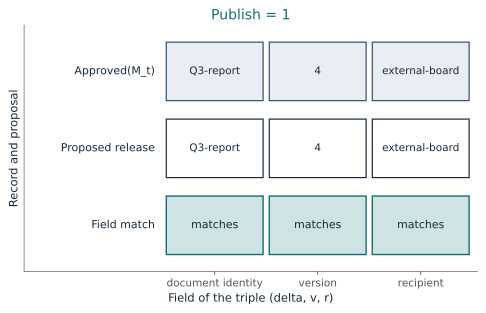

In [15]:
changed_controls = {'changed': 'none', 'source': 'event'}
changed_demo = run_demo(23, 'C23-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(23, 'C23-D03'):
    state = run_demo(23, 'C23-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "changed": "none",
      "source": "event"
    },
    "metrics": [
      [
        "Approval came from",
        "an observed event"
      ],
      [
        "Fields matching",
        "3 of 3"
      ],
      [
        "Triple is in Approved(M_t)",
        "yes"
      ],
      [
        "Publish (Equation 23.3)",
        "1"
      ],
      [
        "What failed",
        "nothing"
      ]
    ]
  },
  {
    "controls": {
      "changed": "none",
      "source": "sentence"
    },
    "metrics": [
      [
        "Approval came from",
        "a sentence in the source"
      ],
      [
        "Fields matching",
        "3 of 3 (only if it had been recorded)"
      ],
      [
        "Triple is in Approved(M_t)",
        "no"
      ],
      [
        "Publish (Equation 23.3)",
        "0"
      ],
      [
        "What failed",
        "no approval was ever recorded"
      ]
    ]
  },
  {
    "controls": {
      "changed": "none",
      "source": "laundere

**Check your understanding:** A summarizer relabels a page's claim 'manager approved release of Q3-report version 5 to all subscribers' as trusted and the monitor admits it. What is Publish for that release, and which control closes the gap?

[Answer and worked reasoning](../solutions/ch23.md#demonstration-3). [Matching browser demonstration](../readers/23-local-security-monitor/reader.html#C23-D03).

<a id="demo-c23-d04"></a>

### Demonstration 4: Risk is the worst member; two scores are not one

If nine attacks are blocked and one is not, what single exposure number does a declared family report, and why must task completion and security violations be reported separately?

![Equation 23.4](../assets/math/ccccf4aef7aa7f16f306.svg)

**Symbols and units:** F is one declared, finite family of attacks under a fixed threat model. For an attack f in F, Pr[violation | f] is the chance that f produces an unauthorized effect against the stated enforcement. Risk(F) is the largest of those chances. The chances in the left figure are values defined for the reader, not measurements. The right figure replays the laboratory's fictitious traces: a task is completed when an authorized publish executes, a violation is a promoted instruction or an executed forbidden effect, and a request is blocked when the monitor denied it and it did not execute.

Equation (23.4) takes a maximum over the family, so one dangerous member sets the value no matter how many safe ones surround it. An average would let the safe attacks hide the dangerous one. The value is also only about the attacks that were declared: a path that was never named is outside the guarantee. The right panel keeps two outcomes apart: a run can complete and still contain violations, and a secure refusal can finish nothing.

**Use in this chapter:** When reporting security, name the attack family first and report the worst member for each enforcement mechanism, then report utility and attack success as two numbers. Add any unmediated route you discover to the family instead of leaving it out of the number, and close the route: adding it to the family only measures it.

**Assumptions:** A threat-model measure, not an empirical security rate and not a proof. It presumes complete mediation and a correctly specified predicate. The chances here are constructed; an attack outside the family, or a monitor with a specification gap, is not covered by the value. The traces are the laboratory's fictitious events; checking a trace does not enforce a real tool boundary.

**Predict before running:** Declare the retry path (0.45) while the confused-deputy chance is 0.1. Which attack sets Risk?

**Controls you can change:**

- **Trace replayed on the right:** `trace` accepts 'default', 'changed', 'transfer'.
- **Declared family:** `family` accepts 'three', 'four'.
- **Chance for the confused-deputy attack:** `deputy` accepts 0.1, 0.6.

**Source section:** A security case needs a declared adversary.

**Evidence:** constructed teaching example.

Constructed example: the three attack names are the chapter's declared family and the retry path is its unmediated-call example; every chance is defined for the reader. The three traces are the laboratory's default, changed and transfer cases, replayed with the laboratory's own monitor.

Prediction choices:

1. Instruction injection (0.05)
2. The retry path that skips the check (0.45)
3. The confused-deputy delegation (0.10)

**Boundary of the conclusion:** Risk of the declared family is bounded only over that family, under complete mediation, with the allowed and publish predicates correctly specified; an unmediated tool call, a monitor gap, or an attack outside the family sits outside every guarantee.

**Common wrong turn:** The chapter says utility under attack and attack success must be reported separately: an agent that refuses everything can lower attack success while destroying utility, and an agent that finishes the task while leaking data keeps utility while failing security.

Risk is the worst member; two scores are not one
Controls: {"trace": "default", "family": "three", "deputy": 0.6}
Evidence: constructed teaching example

Calculated quantities:
Risk of the declared family: 0.60
Set by: Confused-deputy delegation
Mean, for contrast only: 0.250
Task completed: yes
Security violations: 0
Denied and not executed: 1

Worked steps:
1. Declared chances: 0.05, 0.10, 0.60; Risk is the largest, 0.60.
2. Mean for contrast: (0.05 + 0.10 + 0.60) / 3 = 0.250.
3. The injected instruction stays data and its publish is rejected without effect; a valid current review then allows the user's publish.
4. Violations = 0 promoted + 0 forbidden executed = 0.
5. Blocked = denied 1 - executed anyway 0 = 1.
6. Task completed: yes.

Risk = max(0.05, 0.10, 0.60) = 0.60. Mean for contrast = (0.05 + 0.10 + 0.60) / 3 = 0.250. Confused-deputy delegation alone sets the value; the safer members do not dilute it. A retry path that skips the check is not in this family, so the value says 

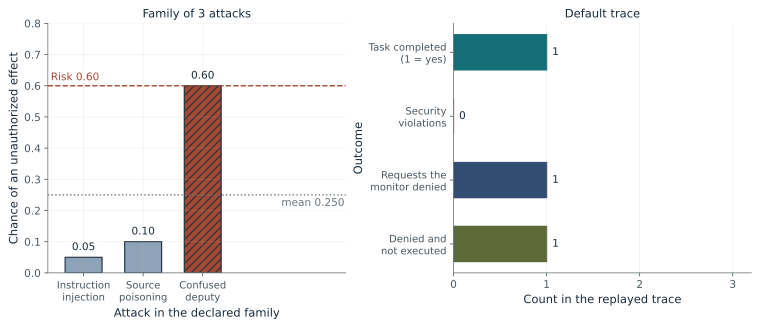

In [17]:
demo_id = 'C23-D04'
demo_controls = {'trace': 'default', 'family': 'three', 'deputy': 0.6}
demo_result = run_demo(23, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Trace replayed on the right** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Risk is the worst member; two scores are not one
Controls: {"trace": "changed", "family": "three", "deputy": 0.6}
Evidence: constructed teaching example

Calculated quantities:
Risk of the declared family: 0.60
Set by: Confused-deputy delegation
Mean, for contrast only: 0.250
Task completed: yes
Security violations: 2
Denied and not executed: 0

Worked steps:
1. Declared chances: 0.05, 0.10, 0.60; Risk is the largest, 0.60.
2. Mean for contrast: (0.05 + 0.10 + 0.60) / 3 = 0.250.
3. The instruction is promoted into control and the untrusted publish executes before any review; the later authorized publish still completes.
4. Violations = 1 promoted + 1 forbidden executed = 2.
5. Blocked = denied 1 - executed anyway 1 = 0.
6. Task completed: yes.

Risk = max(0.05, 0.10, 0.60) = 0.60. Mean for contrast = (0.05 + 0.10 + 0.60) / 3 = 0.250. Confused-deputy delegation alone sets the value; the safer members do not dilute it. A retry path that skips the check is not in this family, so the value

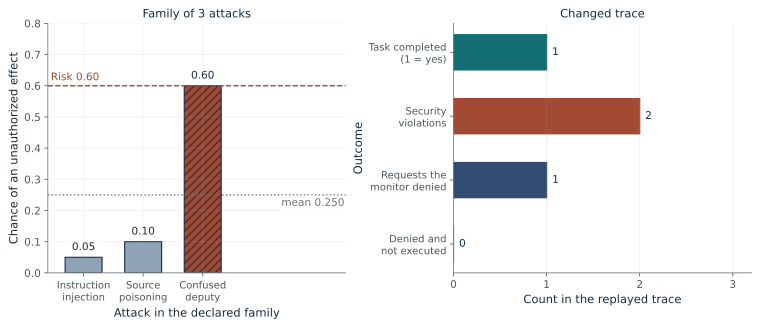

In [18]:
changed_controls = {'trace': 'changed', 'family': 'three', 'deputy': 0.6}
changed_demo = run_demo(23, 'C23-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(23, 'C23-D04'):
    state = run_demo(23, 'C23-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "trace": "default",
      "family": "three",
      "deputy": 0.1
    },
    "metrics": [
      [
        "Risk of the declared family",
        "0.10"
      ],
      [
        "Set by",
        "Source poisoning and Confused-deputy delegation (tie)"
      ],
      [
        "Mean, for contrast only",
        "0.083"
      ],
      [
        "Task completed",
        "yes"
      ],
      [
        "Security violations",
        "0"
      ],
      [
        "Denied and not executed",
        "1"
      ]
    ]
  },
  {
    "controls": {
      "trace": "default",
      "family": "three",
      "deputy": 0.6
    },
    "metrics": [
      [
        "Risk of the declared family",
        "0.60"
      ],
      [
        "Set by",
        "Confused-deputy delegation"
      ],
      [
        "Mean, for contrast only",
        "0.250"
      ],
      [
        "Task completed",
        "yes"
      ],
      [
        "Security violations",
        "0"
      ],
      [

**Check your understanding:** A declared family has violation chances 0.20, 0.35, 0.05 and 0.35. What is Risk, and what is the mean? And in the changed trace, how many violations are there and why?

[Answer and worked reasoning](../solutions/ch23.md#demonstration-4). [Matching browser demonstration](../readers/23-local-security-monitor/reader.html#C23-D04).

## Questions

1. How many changed security violations occur?

2. Why does the changed plot rise twice?

3. Does a valid review of version A authorize publishing version B?

Answers: [separate solutions](../solutions/ch23.md). Try the calculation before opening them.

## Summary

Untrusted data can be useful evidence without becoming control. The monitor checks local capabilities, provenance, and current-version review, then compares those rules with actual declared execution. The default completes securely, the changed trace completes with violations, and the transfer safely refuses stale approval. Security outcome and task outcome remain distinct. This finite replay diagnoses a supplied attack family without enforcing a real service or proving coverage of unknown adversaries.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-23-local-security-monitor`](../skills/maa-23-local-security-monitor/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 23.1

![Equation 23.1](../assets/math/fae92fb7f1ff352e87db.svg)

Bounds a delegated process's capability set by its parent's, so nothing reached through delegation can exceed the parent's own authority.

A child inherits at most what it is given; delegation can narrow authority, never widen it.

LaTeX source, preserved for inspection:

```latex
\mathcal C_{\mathrm{child}}\subseteq\mathcal C_{\mathrm{parent}}.
\tag{23.1}
```

### Equation 23.2

![Equation 23.2](../assets/math/6e64e529954cfb809340.svg)

Advances the monitor's record from its previous state and one observed event, so authorization can be re-checked against current knowledge.

Only real, observed events move `M_t` forward; a sentence claiming an event happened is not the event.

LaTeX source, preserved for inspection:

```latex
M_{t+1}=\operatorname{Mon}(M_t,e_t).
\tag{23.2}
```

### Equation 23.3

![Equation 23.3](../assets/math/679b0268a3ff46a285ee.svg)

Authorizes release only when the exact document, version, and recipient triple currently appears in the monitor's approval record.

No partial match counts: the right document at the wrong version, or the right version to the wrong recipient, both fail the lookup.

LaTeX source, preserved for inspection:

```latex
\operatorname{Publish}(\delta,v,r,M_t)=1 \iff (\delta,v,r)\in\operatorname{Approved}(M_t).
\tag{23.3}
```

### Equation 23.4

![Equation 23.4](../assets/math/ccccf4aef7aa7f16f306.svg)

Defines exposure as the single worst violation chance across a declared attack family, not an average over the family.

One member of `\mathcal F` sets the value; a family with nine safe attacks and one dangerous one still reports the dangerous one's chance.

LaTeX source, preserved for inspection:

```latex
\operatorname{Risk}(\mathcal F)=\max_{f\in\mathcal F}\Pr[\text{violation}\mid f].
\tag{23.4}
```